### NYC Taxi Trip Duration
- Predict the NYC Taxi Trip Duration - Data Science Project

In [63]:
# !pip install -q opendatasets

# import opendatasets as od

# url = "https://www.kaggle.com/datasets/yasserh/nyc-taxi-trip-duration"
# od.download(url)


In [64]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_regression, RFECV, VarianceThreshold
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

In [65]:
pd.set_option('display.max_columns', None)

In [66]:
# base_dir = r"D:\UNV\02_DS\Project\NYC.csv"
base_dir = r"NYC_taxi_with_distances.csv"

if not os.path.exists(base_dir):
    base_dir = [d for d in os.listdir("/content") if "nyc" in d.lower()][0]
    base_dir = os.path.join("/content", base_dir)

# 3) Load dataset
csv_path = os.path.join(base_dir)

df = pd.read_csv(csv_path)

# 4) Basic checks
print(df.shape)
df.head()

(1458644, 12)


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,OSM_distance
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,2158.9
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,2511.3
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,9937.6
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,1777.6
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,1606.4


In [67]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendor_id,1458644.0,1.534950,0.498777,1.000000,1.000000,2.000000,2.000000,2.000000e+00
passenger_count,1458644.0,1.664530,1.314242,0.000000,1.000000,1.000000,2.000000,9.000000e+00
pickup_longitude,1458644.0,-73.973486,0.070902,-121.933342,-73.991867,-73.981743,-73.967331,-6.133553e+01
pickup_latitude,1458644.0,40.750921,0.032881,34.359695,40.737347,40.754101,40.768360,5.188108e+01
dropoff_longitude,1458644.0,-73.973416,0.070643,-121.933304,-73.991325,-73.979752,-73.963013,-6.133553e+01
dropoff_latitude,1458644.0,40.751800,0.035891,32.181141,40.735885,40.754524,40.769810,4.392103e+01
trip_duration,1458644.0,959.492273,5237.431724,1.000000,397.000000,662.000000,1075.000000,3.526282e+06
OSM_distance,1458524.0,4606.367743,5339.347729,0.000000,1665.200000,2758.700000,5059.700000,8.063490e+04


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 12 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
 11  OSM_distance        1458524 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 133.5+ MB


## Step 1: Data Tidying & Data Cleaning Report

### 1. Type Corrections
We converted the `pickup_datetime` and `dropoff_datetime` columns from object strings to **datetime objects**. This was a fundamental step to enable time-series analysis and to extract temporal features such as hours and days of the week, which are critical predictors for trip duration.

### 2. Basic Cleansing & Duplicate Removal
We performed a check for redundant data and removed all exact duplicates to prevent the model from being biased toward repeated observations.

### 3. Handling Inconsistent Entries (Outlier Management)
To ensure data integrity, we applied the following filters:
* **Temporal Filtering:** Trips shorter than 1 minute or longer than 3 hours were removed, as they often represent system errors or stationary taxis rather than actual trips.
* **Geographical Filtering:** We restricted the coordinates to the NYC bounding box. Any coordinates outside this range were treated as GPS noise.
* **Spatial Validation:** By constructing the `distance_km` feature using the **Haversine Formula**, we identified and removed trips with zero distance (which are logically invalid for duration prediction).

### 4. Imputation Techniques
For missing values in the `passenger_count` column, we applied **Mode Imputation**. We chose the mode (most frequent value) because the number of passengers is a discrete, categorical-like variable, and using the mean would result in illogical decimal values (e.g., 1.5 passengers).

### 5. Data Tidying with Pivot Tables
We utilized **Pivot Tables** to restructure the data and verify its cleanliness. By aggregating the average trip duration by hour and day, we ensured that the cleaned dataset reflects realistic traffic patterns (e.g., higher durations during rush hours), confirming that our cleaning process preserved the essential characteristics of the data.

In [69]:
df.sample()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,OSM_distance
838091,id0042534,2,2016-01-08 15:48:03,2016-01-08 15:56:15,1,-73.962914,40.763088,-73.979698,40.746487,N,492,2663.5


In [70]:
# --- Step 2: Data Tidying & Data Cleaning ---

# [A] Type Corrections
# Converting date columns from strings to datetime objects for time-series analysis
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['dropoff_datetime'] = pd.to_datetime(df['dropoff_datetime'])

# Data Type Enforcement: Convert coordinate columns to numeric (float)
# This prevents errors during mathematical calculations (like Haversine)
cols_to_fix = ['pickup_latitude', 'pickup_longitude', 'dropoff_latitude', 'dropoff_longitude']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove rows that became NaN during numeric conversion to maintain data quality
df.dropna(subset=cols_to_fix, inplace=True)

# [B] Feature Construction: Calculating Trip Distance
def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculates the great-circle distance between two points
    on the Earth using the Haversine formula.
    """
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))
  # Result in Kilometers (Earth radius = 6371km)

# Apply the function to create a new distance column
df['distance_km'] = haversine_distance(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

# [C] Basic Cleansing
# Removing exact duplicate rows to avoid model bias
df.drop_duplicates(inplace=True)

# [D] Handling Inconsistent Entries & Outliers
# Ensure trip_duration is numeric before filtering
df['trip_duration'] = pd.to_numeric(df['trip_duration'], errors='coerce')

# 1. Temporal Filtering: Remove trips shorter than 1 minute or longer than 3 hours
df = df[(df['trip_duration'] > 60) & (df['trip_duration'] < 10800)]

# 2. Geographical Filtering: Restrict coordinates to the NYC metropolitan area
df = df[df['pickup_longitude'].between(-74.25, -73.70)]
df = df[df['pickup_latitude'].between(40.47, 40.92)]

# 3. Spatial Validation: Remove trips with zero distance or unrealistic lengths (>100km)
df = df[(df['distance_km'] > 0.1) & (df['distance_km'] < 100)]

# [E] Imputation: Handling Missing Values
# Fill missing passenger counts with the Mode (Most frequent value)
if df['passenger_count'].isnull().sum() > 0:
    df['passenger_count'].fillna(df['passenger_count'].mode()[0], inplace=True)

# ── [E] Passenger imputation (mode) ───────────────────────────────────────────
if df["passenger_count"].isnull().sum() > 0:
    mode_val = df["passenger_count"].mode()[0]
    df["passenger_count"].fillna(mode_val, inplace=True)

# Create a Pivot Table to analyze average duration per hour across different days
# This helps verify if the cleaned data follows realistic traffic patterns
# ── [F] Extract hour/day for pivot analysis ───────────────────────────────────
df["pickup_hour"] = df["pickup_datetime"].dt.hour
df["pickup_day"]  = df["pickup_datetime"].dt.day_name()

cleaning_summary_pivot = df.pivot_table(
    index="pickup_hour",
    columns="pickup_day",
    values="trip_duration",
    aggfunc="mean",
)

# Final Output Status
print("Data Cleaning Process Finished Successfully.")
print(f"Final records count: {df.shape[0]}")

Data Cleaning Process Finished Successfully.
Final records count: 1440222


In [71]:
df = df.dropna(subset=['OSM_distance'])

In [72]:
cleaning_summary_pivot

pickup_day,Friday,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
pickup_hour,,,,,,,
0,804.441190,725.887524,836.563582,801.123092,749.004355,747.939455,741.567904
1,746.881107,705.079041,768.025036,777.267619,694.157939,697.842250,694.795918
2,705.127676,699.155364,727.383751,712.808002,691.482253,693.317687,654.787372
3,706.567776,726.207297,711.761977,716.745602,716.001988,679.227503,689.209768
4,779.973463,772.164894,745.478388,732.164046,733.456296,748.526457,721.829388
5,746.230579,745.077984,789.018916,770.486670,692.590345,669.022564,654.244748
6,689.786706,693.498108,716.131558,735.149644,669.443570,650.801930,648.905108
7,763.195785,800.736428,633.951573,654.083095,780.173634,780.564250,775.314515
8,854.668196,883.619434,630.310881,593.029142,892.476582,882.706661,874.451558


In [73]:
print("Min avg duration by day:")
print(cleaning_summary_pivot.min().round(0))
print("\nMax avg duration by day:")
print(cleaning_summary_pivot.max().round(0))

Min avg duration by day:
pickup_day
Friday       690.0
Monday       693.0
Saturday     630.0
Sunday       593.0
Thursday     669.0
Tuesday      651.0
Wednesday    649.0
dtype: float64

Max avg duration by day:
pickup_day
Friday       1065.0
Monday        915.0
Saturday      854.0
Sunday        891.0
Thursday     1101.0
Tuesday       984.0
Wednesday    1070.0
dtype: float64


In [74]:
# --- Validation & Sanity Checks ---
print("1. Checking for Missing Values:")
print(df.isnull().sum())
print("-" * 30)

print("2. Checking for Duplicates:")
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

1. Checking for Missing Values:
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
OSM_distance          0
distance_km           0
pickup_hour           0
pickup_day            0
dtype: int64
------------------------------
2. Checking for Duplicates:
Total Duplicate Rows: 0


In [75]:
print("3. Checking Coordinate Ranges (Should be within NYC):")
print(f"Latitude Range:  {df['pickup_latitude'].min()} to {df['pickup_latitude'].max()}")
print(f"Longitude Range: {df['pickup_longitude'].min()} to {df['pickup_longitude'].max()}")
print("-" * 30)

print("4. Checking Trip Logic (Should be > 1 min and > 0.1 km):")
print(f"Minimum Duration: {df['trip_duration'].min()} seconds")
print(f"Minimum Distance: {df['distance_km'].min():.2f} km")
print("-" * 30)

print("5. Data Types Verification:")
print(df[['pickup_datetime', 'distance_km', 'passenger_count']].dtypes)

3. Checking Coordinate Ranges (Should be within NYC):
Latitude Range:  40.50629425048828 to 40.91659927368164
Longitude Range: -74.23101043701173 to -73.70709991455078
------------------------------
4. Checking Trip Logic (Should be > 1 min and > 0.1 km):
Minimum Duration: 61 seconds
Minimum Distance: 0.10 km
------------------------------
5. Data Types Verification:
pickup_datetime    datetime64[ns]
distance_km               float64
passenger_count             int64
dtype: object


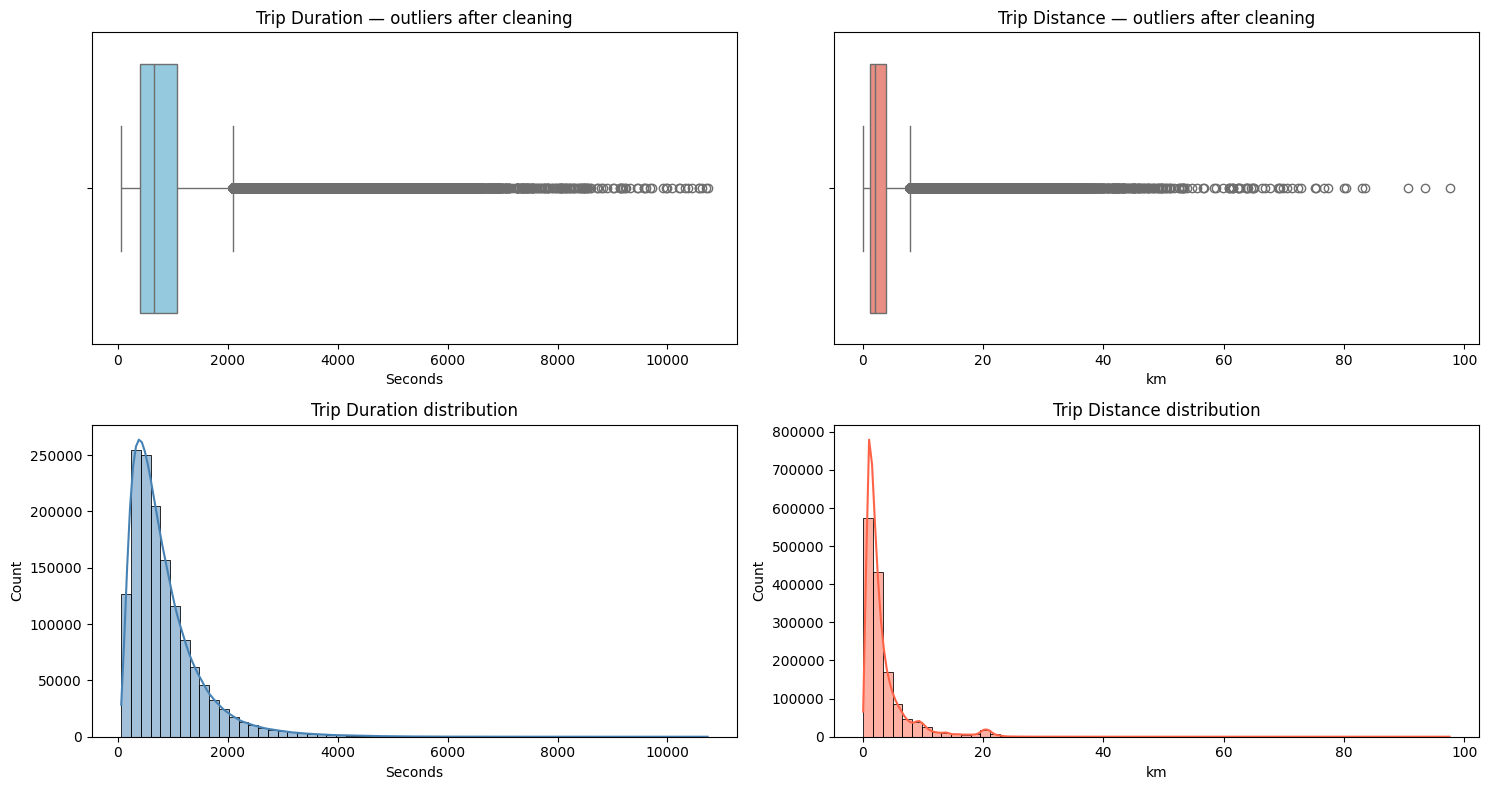

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

sns.boxplot(x=df["trip_duration"],   ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("Trip Duration — outliers after cleaning")
axes[0, 0].set_xlabel("Seconds")

sns.boxplot(x=df["distance_km"],     ax=axes[0, 1], color="salmon")
axes[0, 1].set_title("Trip Distance — outliers after cleaning")
axes[0, 1].set_xlabel("km")

sns.histplot(df["trip_duration"],    ax=axes[1, 0], bins=60, kde=True, color="steelblue")
axes[1, 0].set_title("Trip Duration distribution")
axes[1, 0].set_xlabel("Seconds")

sns.histplot(df["distance_km"],      ax=axes[1, 1], bins=60, kde=True, color="tomato")
axes[1, 1].set_title("Trip Distance distribution")
axes[1, 1].set_xlabel("km")

plt.tight_layout()
plt.show()

## Feature Extraction --> ***Anas***

In [77]:
df.sample(3)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,OSM_distance,distance_km,pickup_hour,pickup_day
865171,id1424240,2,2016-03-24 16:02:57,2016-03-24 16:17:31,6,-73.997452,40.757069,-73.977859,40.763821,N,874,2521.6,1.812914,16,Thursday
587126,id0146019,2,2016-03-29 10:18:55,2016-03-29 10:31:17,1,-73.986435,40.762081,-73.987656,40.753433,N,742,1362.1,0.967086,10,Tuesday
1327152,id0779811,1,2016-02-20 16:31:03,2016-02-20 16:37:35,1,-73.969574,40.800491,-73.977806,40.787277,N,392,1725.6,1.624564,16,Saturday


### Rush Hour Feature
This feature checks if the trip happened during peak traffic hours (morning or evening).  
It helps the model understand traffic impact on trip duration.

In [78]:
# df['rush_hour'] = df['pickup_hour'].apply(lambda x: 1 if (7 <= x <= 9 or 16 <= x <= 19) else 0)

#### Rush Hour and Congestion Analysis

| Feature | Time Window | Rationale | Data-Driven Insight |
|---------|-------------|-----------|-------------------|
| **afternoon_peak** | 14–16 | True peak congestion period | Pivot table showed 14–16 as genuine peak (~1000–1023s avg) |
| **midday_busy** | 10–15 | Extended midday congestion window | Broader coverage of daytime traffic (10–15 range) |
| **evening_rush** | 17–21 | Evening commute (deprecated) | Declining phase; NOT the actual peak—already falling from afternoon max |

#### Key Findings

- **Weekday vs Weekend Contrast:** Weekday patterns show clear morning and afternoon peaks; weekends have flatter, elevated evening durations
- **Thursday/Friday Effect:** Thu/Fri consistently ~15% longer than Mon/Tue at same hour
- **Why Not 17–21?** Pivot analysis revealed this window is already in the descending phase; 14–16 captures the true congestion maximum
- **Hour 10 Observation:** Still shows ~925s average—justifies extending morning window to include it

In [79]:
# ── Temporal Feature Engineering ──────────────────────────────────────────────
# Based on empirical analysis of avg trip duration from pivot table:
#   - Weekday peak congestion:  14–16  (~1000–1023s avg)
#   - Weekday morning traffic:   7–10  (~800–920s avg)
#   - Weekend pattern: opposite shape — evening stays elevated, morning is fast
#   - Thursday/Friday consistently ~15% longer than Mon/Tue at same hour

# ── Temporal features ─────────────────────────────────────────────────────────
df["is_weekend"]  = (df["pickup_datetime"].dt.dayofweek >= 5).astype(int)
df["day_of_week"] = df["pickup_datetime"].dt.dayofweek
df["month"]       = df["pickup_datetime"].dt.month
df["hour_sin"]    = np.sin(2 * np.pi * df["pickup_hour"] / 24)
df["hour_cos"]    = np.cos(2 * np.pi * df["pickup_hour"] / 24)


# 1. Weekend flag
is_weekday = ~df["is_weekend"].astype(bool)

# 2. Data-driven congestion windows (from pivot table, NOT assumptions)
df["afternoon_peak"] = (is_weekday & df["pickup_hour"].between(14, 16)).astype(int)

# FIX problem 6 — morning rush (7-10) was shown in pivot but never created
df["morning_rush"] = (is_weekday & df["pickup_hour"].between(7, 10)).astype(int)

# NEW — late night has distinct (faster) traffic dynamics
df["late_night"] = (
    (df["pickup_hour"] >= 22) | (df["pickup_hour"] == 0)
).astype(int)


# 4. DROP the old rush_hour — it was pointing at 17–21 which pivot showed
#    is already the DECLINING phase, not the peak
#    hour_sin + hour_cos + day_of_week replace it more faithfully

print("Temporal feature validation:")
print(df.groupby("morning_rush")["trip_duration"].mean().rename("mean_duration"))
print(df.groupby("afternoon_peak")["trip_duration"].mean().rename("mean_duration"))
print(df.groupby("late_night")["trip_duration"].mean().rename("mean_duration"))
print(df.groupby("day_of_week")["trip_duration"].mean().rename("mean_duration"))

Temporal feature validation:
morning_rush
0    837.204982
1    874.358025
Name: mean_duration, dtype: float64
afternoon_peak
0     823.500417
1    1010.700775
Name: mean_duration, dtype: float64
late_night
0    848.363412
1    806.246191
Name: mean_duration, dtype: float64
day_of_week
0    815.534821
1    860.561755
2    884.646330
3    903.246186
4    872.738667
5    783.365879
6    768.337595
Name: mean_duration, dtype: float64


### Trip Direction
This feature calculates the direction of the trip using pickup and dropoff coordinates.  
It may help capture movement patterns across the city.  
It is computed by taking the arctangent (atan2) of the difference in latitude (Y-axis) and longitude (X-axis) between dropoff and pickup points to obtain the trip angle.


In [80]:
df["direction_rad"] = np.arctan2(
    df["dropoff_latitude"]  - df["pickup_latitude"],
    df["dropoff_longitude"] - df["pickup_longitude"],
)

### Average Speed
This feature estimates the trip speed (km/h) based on distance and duration.  
It helps identify abnormal trips and traffic conditions.

In [81]:
df["speed_kmh"] = df["distance_km"] / (df["trip_duration"] / 3600)

# Remove physically impossible speeds
df = df[(df["speed_kmh"] > 0.5) & (df["speed_kmh"] < 120)]

print(f"Records after speed filter: {df.shape[0]:,}")
print(df["speed_kmh"].describe().round(2))

Records after speed filter: 1,439,593
count    1439593.00
mean          14.48
std            7.63
min            0.50
25%            9.23
50%           12.86
75%           17.89
max          117.62
Name: speed_kmh, dtype: float64


In [82]:
df.to_csv("NYC_taxi_cleaned.csv", index=False)

##### Speed Feature (For Analysis Only)

In this step, we calculate the average speed of each trip using distance and trip duration.

However, this feature is not used for model training.

The reason is that speed is calculated using the target variable (trip_duration). This creates a problem called data leakage, where the model indirectly gets access to the answer it is supposed to predict.

If we include speed as a feature, the model can easily infer the trip duration, leading to unrealistically high performance that does not reflect real-world behavior.

Instead, we use this feature for:
- Data Cleaning: to detect and remove unrealistic trips (e.g., extremely high or very low speeds)
- Exploratory Data Analysis (EDA): to better understand traffic patterns and trip behavior

This ensures that our model remains fair, realistic, and generalizable.

### Time Features
We extract if the trip is on a weekend and the month of the trip.  
This helps capture seasonal and weekly patterns.

In [83]:
# df['is_weekend'] = df['pickup_datetime'].dt.dayofweek >= 5
df['month'] = df['pickup_datetime'].dt.month

### Distance per Passenger
This feature divides trip distance by number of passengers.  
It may reflect ride-sharing patterns or trip efficiency.

In [84]:
df["distance_per_passenger"] = np.where(
    df["passenger_count"] > 0,
    df["distance_km"] / df["passenger_count"],
    0,
)
#df['distance_per_passenger'] = df['distance_km'] / df['passenger_count']

### Log Transformation of Duration
We apply log transformation to reduce Skewed Distribution in trip duration.  
The goal is removing outliers.

In [85]:
# ── Log-transform target ──────────────────────────────────────────────────────
df["log_trip_duration"] = np.log1p(df["trip_duration"])

### Location Clustering (KMeans)

In this step, we apply clustering on the pickup and dropoff coordinates to group similar locations into clusters.

Instead of using raw latitude and longitude values directly, we transform them into cluster labels. This helps simplify the spatial information and makes it easier for the model to understand location-based patterns.

The main idea is that nearby locations usually share similar traffic conditions and travel behavior. For example, trips starting in the same area (like city center or airport) often have similar durations.

By grouping coordinates into clusters, we allow the model to learn:
- differences between regions
- traffic behavior in each area
- patterns related to specific zones

This approach improves model performance because it reduces noise in raw coordinates and captures meaningful geographic structure in the data.

In [86]:
coords = pd.concat([
    df[["pickup_latitude",  "pickup_longitude"]].rename(
        columns={"pickup_latitude": "lat", "pickup_longitude": "lon"}),
    df[["dropoff_latitude", "dropoff_longitude"]].rename(
        columns={"dropoff_latitude": "lat", "dropoff_longitude": "lon"}),
])

In [87]:
coord_scaler    = StandardScaler()
coords_scaled   = coord_scaler.fit_transform(coords)

kmeans = KMeans(n_clusters=40, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(coords_scaled)

KMeans(n_clusters=40, n_init=10, random_state=42)

In [88]:

pickup_scaled          = coord_scaler.transform(
    df[["pickup_latitude", "pickup_longitude"]].rename(
        columns={"pickup_latitude": "lat", "pickup_longitude": "lon"}))
df["pickup_cluster"]   = kmeans.predict(pickup_scaled)

dropoff_scaled         = coord_scaler.transform(
    df[["dropoff_latitude", "dropoff_longitude"]].rename(
        columns={"dropoff_latitude": "lat", "dropoff_longitude": "lon"}))
df["dropoff_cluster"]  = kmeans.predict(dropoff_scaled)

print(f"Clusters assigned. Unique pickup clusters  : {df['pickup_cluster'].nunique()}")
print(f"Clusters assigned. Unique dropoff clusters : {df['dropoff_cluster'].nunique()}")

Clusters assigned. Unique pickup clusters  : 38
Clusters assigned. Unique dropoff clusters : 40


In [89]:
# ── NEW: Distance from Midtown Manhattan ─────────────────────────────────────
MIDTOWN_LAT, MIDTOWN_LON = 40.7549, -73.9840
df["dist_from_midtown"] = haversine_distance(
    df["pickup_latitude"], df["pickup_longitude"],
    MIDTOWN_LAT, MIDTOWN_LON,
)

In [90]:
JFK_LAT, JFK_LON = 40.6413, -73.7781
LGA_LAT, LGA_LON = 40.7769, -73.8740

# Distance to JFK
df["pickup_jfk"] = haversine_distance(df["pickup_latitude"], df["pickup_longitude"], JFK_LAT, JFK_LON)
df["dropoff_jfk"] = haversine_distance(df["dropoff_latitude"], df["dropoff_longitude"], JFK_LAT, JFK_LON)

# Distance to LGA
df["pickup_lga"] = haversine_distance(df["pickup_latitude"], df["pickup_longitude"], LGA_LAT, LGA_LON)
df["dropoff_lga"] = haversine_distance(df["dropoff_latitude"], df["dropoff_longitude"], LGA_LAT, LGA_LON)

# Flag if a trip is likely an airport trip (within ~2km of the airport)
df["is_jfk_trip"] = ((df["pickup_jfk"] < 2) | (df["dropoff_jfk"] < 2)).astype(int)
df["is_lga_trip"] = ((df["pickup_lga"] < 2) | (df["dropoff_lga"] < 2)).astype(int)

# Route Circuity (How winding is the road compared to a straight line?)
# Requires 'distance_km' to not be zero to avoid division by zero
df["circuity"] = np.where(
    df["distance_km"] > 0, 
    df["OSM_distance"] / df["distance_km"], 
    1.0
)

In [91]:
df.sample(3)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,OSM_distance,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,month,hour_sin,hour_cos,afternoon_peak,morning_rush,late_night,direction_rad,speed_kmh,distance_per_passenger,log_trip_duration,pickup_cluster,dropoff_cluster,dist_from_midtown,pickup_jfk,dropoff_jfk,pickup_lga,dropoff_lga,is_jfk_trip,is_lga_trip,circuity
1173787,id1477332,2,2016-04-12 16:58:55,2016-04-12 17:10:13,1,-73.988426,40.778629,-73.984016,40.759399,N,678,2976.2,2.170275,16,Tuesday,0,1,4,-0.866025,-0.500000,1,0,0,-1.345374,11.523582,2.170275,6.520621,12,32,2.664778,23.397944,21.766454,9.636856,9.467122,0,0,1371.347138
466659,id3134052,2,2016-05-23 20:51:33,2016-05-23 20:58:00,2,-73.966644,40.767231,-73.973755,40.779213,N,387,2080.7,1.460697,20,Monday,0,0,5,-0.866025,0.500000,0,0,0,2.106380,13.587883,0.730349,5.961005,18,12,2.004187,21.182079,22.519580,7.875257,8.403480,0,0,1424.456569
1408048,id0648405,2,2016-05-09 09:04:27,2016-05-09 09:14:54,1,-73.959557,40.809010,-73.978912,40.781700,N,627,3951.8,3.446185,9,Monday,0,0,5,0.707107,-0.707107,0,1,0,-2.187376,19.786710,3.446185,6.442540,15,12,6.358961,24.116032,23.026211,8.038813,8.849757,0,0,1146.717179


#### Feature Engineering Ashraf
- handle some features that was added

In [92]:
df.groupby('afternoon_peak')[['trip_duration', 'distance_km', 'speed_kmh']].mean()

,trip_duration,distance_km,speed_kmh
afternoon_peak,,,
0,823.005160,3.476062,14.802066
1,1009.880812,3.449520,11.650791


In [93]:
NYC_LAT_DEG = 40.7128
LAT_KM      = 111.0
LON_KM      = 111.0 * np.cos(np.radians(NYC_LAT_DEG))   # ≈ 84.7 km / degree

df["manhattan_distance_km"] = (
    np.abs(df["pickup_latitude"]  - df["dropoff_latitude"])  * LAT_KM +
    np.abs(df["pickup_longitude"] - df["dropoff_longitude"]) * LON_KM
)

print(f"Longitude km-per-degree at NYC latitude: {LON_KM:.2f}")
print(df[["distance_km", "manhattan_distance_km"]].describe().T.round(3))

Longitude km-per-degree at NYC latitude: 84.14
                           count   mean    std    min    25%    50%    75%  \
distance_km            1439593.0  3.473  3.946  0.100  1.257  2.118  3.910   
manhattan_distance_km  1439593.0  4.482  5.232  0.102  1.601  2.716  5.036   

                           max  
distance_km             97.586  
manhattan_distance_km  128.181  


In [94]:
df.sample(5)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,OSM_distance,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,month,hour_sin,hour_cos,afternoon_peak,morning_rush,late_night,direction_rad,speed_kmh,distance_per_passenger,log_trip_duration,pickup_cluster,dropoff_cluster,dist_from_midtown,pickup_jfk,dropoff_jfk,pickup_lga,dropoff_lga,is_jfk_trip,is_lga_trip,circuity,manhattan_distance_km
297544,id1358386,2,2016-02-12 05:04:39,2016-02-12 05:06:15,1,-74.000168,40.742821,-73.995262,40.749908,N,96,900.3,0.889897,5,Friday,0,4,2,0.965926,2.588190e-01,0,0,0,0.965364,33.371152,0.889897,4.574711,20,3,1.912850,21.862559,21.932485,11.281922,10.644628,0,0,1011.689677,1.199485
675472,id2142017,1,2016-05-10 11:17:55,2016-05-10 11:25:02,1,-73.953743,40.775009,-73.960823,40.769817,N,427,1026.3,0.829903,11,Tuesday,0,1,5,0.258819,-9.659258e-01,0,0,0,-2.508867,6.996843,0.829903,6.059123,1,24,3.390158,20.981870,21.010738,6.718008,7.353472,0,0,1236.650019,1.171985
254556,id0782216,1,2016-06-12 09:26:03,2016-06-12 09:40:09,3,-73.992226,40.748684,-74.016624,40.715652,N,846,4815.3,4.209146,9,Sunday,1,6,6,0.707107,-7.071068e-01,0,0,0,-2.206996,17.911260,1.403049,6.741701,3,0,0.978696,21.643975,21.747115,10.439717,13.810920,0,0,1144.008750,5.719328
1324704,id3560641,1,2016-04-15 18:25:22,2016-04-15 18:32:46,1,-74.002373,40.733673,-74.003868,40.746685,N,444,2031.3,1.452335,18,Friday,0,4,4,-1.000000,-1.836970e-16,0,0,0,1.685217,11.775693,1.452335,6.098074,22,20,2.822557,21.519430,22.352079,11.833123,11.442183,0,0,1398.643801,1.570139
1281225,id3065835,1,2016-02-04 09:30:11,2016-02-04 09:46:55,1,-73.978630,40.752235,-73.992317,40.741970,N,1004,2558.5,1.622458,9,Thursday,0,3,2,0.707107,-7.071068e-01,0,1,0,-2.498092,5.817580,1.622458,6.912743,5,3,0.540726,20.927585,21.248582,9.228764,10.695477,0,0,1576.928018,2.291045


- Convert `arctan2` angles to cardinal buckets (N, S, E, W) to avoid circular continuity issues in models
- One-hot encode `df['cardinal_direction']` for clean, orthogonal features compatible with linear and tree-based models
- Aligns with NYC street grid: Avenues (N/S) and Streets (E/W) have distinct traffic dynamics models can learn separately
- Eliminates edge-case confusion at angle boundaries (e.g., π vs -π both map to West)
- Improves model interpretability: coefficients or splits correspond to intuitive geographic directions

In [95]:
df["direction_deg"] = np.degrees(df["direction_rad"])


def direction_to_cardinal(angle_deg: float) -> str:
    """Map a bearing in DEGREES [-180, 180] to a cardinal direction."""
    if   -45  <= angle_deg <  45:  return "East"
    elif  45  <= angle_deg < 135:  return "North"
    elif -135 <= angle_deg < -45:  return "South"
    else:                          return "West"

In [96]:
df["cardinal_direction"] = df["direction_deg"].apply(direction_to_cardinal)

In [97]:
df.to_csv("NYC_taxi_features.csv", index=False)

In [98]:
print("Cardinal direction distribution (should be roughly balanced):")
print(df["cardinal_direction"].value_counts())
print("")
print("Mean trip duration by direction:")
print(df.groupby("cardinal_direction")["trip_duration"].mean().round(1))

Cardinal direction distribution (should be roughly balanced):
cardinal_direction
North    406193
South    391020
East     335860
West     306520
Name: count, dtype: int64

Mean trip duration by direction:
cardinal_direction
East     870.1
North    747.9
South    804.7
West     983.2
Name: trip_duration, dtype: float64


In [99]:
df.groupby(['afternoon_peak', 'cardinal_direction'])['trip_duration'].mean().unstack()

cardinal_direction,East,North,South,West
afternoon_peak,,,,
0,839.987071,736.93502,799.698017,949.77286
1,1144.414554,845.79202,852.087549,1250.01321


### Pickup hour analysis

In [100]:
df.sample()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,OSM_distance,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,month,hour_sin,hour_cos,afternoon_peak,morning_rush,late_night,direction_rad,speed_kmh,distance_per_passenger,log_trip_duration,pickup_cluster,dropoff_cluster,dist_from_midtown,pickup_jfk,dropoff_jfk,pickup_lga,dropoff_lga,is_jfk_trip,is_lga_trip,circuity,manhattan_distance_km,direction_deg,cardinal_direction
683713,id1035561,1,2016-03-17 23:00:08,2016-03-17 23:07:55,1,-73.983566,40.765965,-73.963715,40.774269,N,467,2642.4,1.909833,23,Thursday,0,3,3,-0.258819,0.965926,0,0,1,0.396209,14.722482,1.909833,6.148468,11,24,1.230859,22.184202,21.52662,9.306382,7.560076,0,0,1383.576457,2.592066,22.701121,East


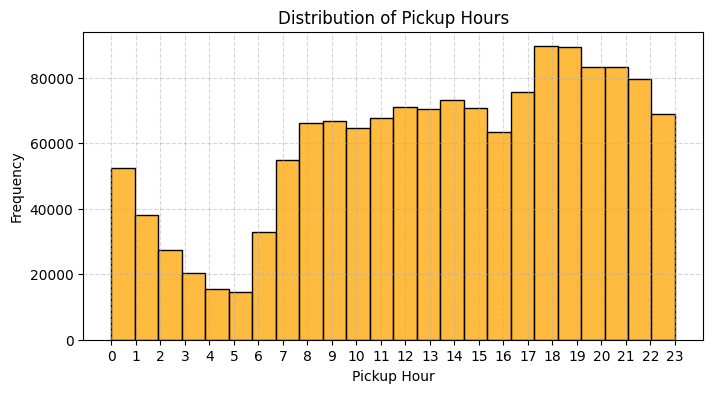

In [101]:
#plot hist for pickup hours
plt.figure(figsize=(8, 4))
sns.histplot(df['pickup_hour'], bins=24, kde=False, color='orange')
plt.title('Distribution of Pickup Hours')
plt.xlabel('Pickup Hour')
plt.ylabel('Frequency')
plt.xticks(range(24), rotation=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

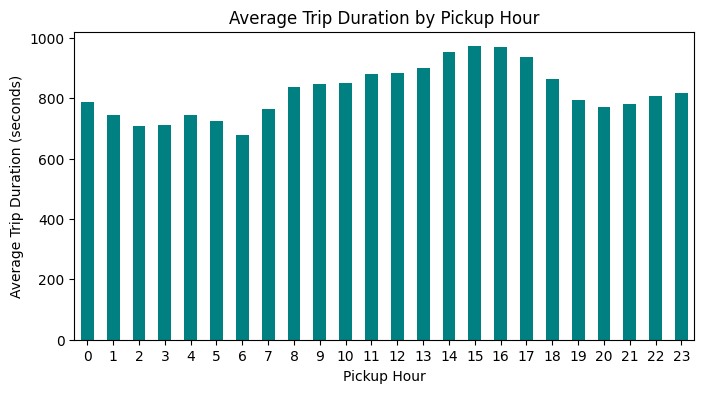

In [102]:
df.groupby('pickup_hour')['trip_duration'].mean().plot(kind='bar', figsize=(8, 4), color='teal')
plt.title('Average Trip Duration by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Trip Duration (seconds)')
plt.xticks(rotation=0)
plt.show()

#### Trip duration into 3 classes short, medium, long for thresholds [>600>1200] seconds.

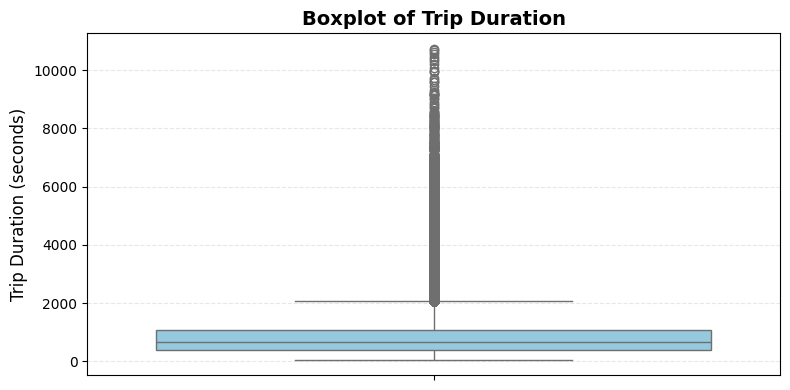

In [103]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, y='trip_duration', color='skyblue')
plt.title('Boxplot of Trip Duration', fontsize=14, fontweight='bold')
plt.ylabel('Trip Duration (seconds)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [109]:
df['trip_duration'].describe().T

count    1.439593e+06
mean     8.419571e+02
std      6.557965e+02
min      6.100000e+01
25%      4.020000e+02
50%      6.660000e+02
75%      1.076000e+03
max      1.073100e+04
Name: trip_duration, dtype: float64

In [111]:
#outliers in trip duration ,we will calc number of outliers using IQR method
Q1 = df['trip_duration'].quantile(0.25)
Q3 = df['trip_duration'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['trip_duration'] < lower_bound) | (df['trip_duration'] > upper_bound)]
print(f"Lower bound: {lower_bound:.2f} seconds")
print(f"Upper bound: {upper_bound:.2f} seconds")
print(f"Number of outliers in trip duration: {outliers.shape[0]}")
# drop outliers
print(f"Records before dropping outliers: {df.shape[0]:,}")
df = df[(df['trip_duration'] >= lower_bound) & (df['trip_duration'] <= upper_bound)]
print(f"Records after dropping outliers: {df.shape[0]:,}")

Lower bound: -609.00 seconds
Upper bound: 2087.00 seconds
Number of outliers in trip duration: 72047
Records before dropping outliers: 1,439,593
Records after dropping outliers: 1,367,546


In [112]:
# ── Trip duration category (used only for stratified split) ──────────────────
def categorize_duration(s):
    if s < 600:    return "short"
    elif s < 1200: return "medium"
    else:          return "long"

df["tripduration_cat"] = df["trip_duration"].apply(categorize_duration)

print("Category distribution:")
print(df["tripduration_cat"].value_counts())

Category distribution:
tripduration_cat
short     638385
medium    508925
long      220236
Name: count, dtype: int64


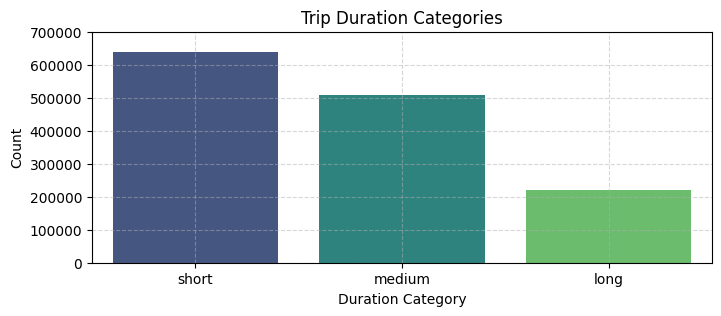

In [113]:
plt.figure(figsize=(8, 3))
sns.barplot(x=df['tripduration_cat'].value_counts().index, y=df['tripduration_cat'].value_counts().values, palette='viridis')
plt.title('Trip Duration Categories')
plt.xlabel('Duration Category')
plt.ylabel('Count')
plt.yticks(np.arange(0, df['tripduration_cat'].value_counts().max() + 90000, 100000))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [107]:
df.sample()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,OSM_distance,distance_km,pickup_hour,pickup_day,is_weekend,day_of_week,month,hour_sin,hour_cos,afternoon_peak,morning_rush,late_night,direction_rad,speed_kmh,distance_per_passenger,log_trip_duration,pickup_cluster,dropoff_cluster,dist_from_midtown,pickup_jfk,dropoff_jfk,pickup_lga,dropoff_lga,is_jfk_trip,is_lga_trip,circuity,manhattan_distance_km,direction_deg,cardinal_direction,tripduration_cat
386312,id0689129,1,2016-03-17 21:09:23,2016-03-17 21:15:20,2,-73.986504,40.761833,-73.982079,40.776764,N,357,1827.2,1.701528,21,Thursday,0,3,3,-0.707107,0.707107,0,0,0,1.282671,17.158269,0.850764,5.880533,32,12,0.799255,22.096863,22.858184,9.621235,9.100592,0,0,1073.858112,2.02962,73.491651,North,short


In [114]:
df['log_trip_duration'].describe().T

count    1.367546e+06
mean     6.406239e+00
std      6.601453e-01
min      4.127134e+00
25%      5.968708e+00
50%      6.456770e+00
75%      6.902743e+00
max      7.643962e+00
Name: log_trip_duration, dtype: float64

- **Stratified Split:** Use `df['tripduration_cat']` as the `stratify` argument in `train_test_split` to ensure proportional class distribution in both splits.
- **Resample Training Only:** Apply `RandomUnderSampler` exclusively to `X_train` and `y_train` to balance the training classes.
- **Preserve Test Set:** Leave the test set completely untouched; **never** apply resampling or modifications to it.
- **Drop Pre-Modeling:** Remove the `tripduration_cat` column from both the resampled training set and the original test set before model training/evaluation.

##### Some Featuers needed to be dropped as they were Superseded by other features or was just for EDA, split data and So on.

In [146]:
# df.drop(columns=['pickup_hour','month','direction','tripduration_cat','pickup_day'], inplace=True)

# **Step 3: Feature Selection**
# Overview

We evaluate multiple feature selection techniques spanning:

Filter methods → fast, scalable

Statistical tests → relationship strength

Embedded methods → model-driven

Wrapper methods → optimal subset search

In [147]:
numerical_features = [
    "OSM_distance",
    "distance_km",               # Keep this to contrast with OSM_distance
    "dist_from_midtown",
    "passenger_count",
    "hour_sin",
    "hour_cos",
    "day_of_week",
    "is_weekend",
    "morning_rush",
    "afternoon_peak",
    "late_night",
    "month",                     # Un-comment this (seasonal effects matter!)
    "pickup_cluster",
    "dropoff_cluster",
    "direction_deg",             # Raw angle is useful for trees
    "is_jfk_trip",               # NEW
    "is_lga_trip",               # NEW
    "circuity"                   # NEW
]

# df.drop(columns=['pickup_hour','month','direction','tripduration_cat','pickup_day'], inplace=True)

In [148]:
# One-hot encode cardinal_direction once, cleanly
df_encoded = pd.get_dummies(
    df[numerical_features + [
        "cardinal_direction",
        "log_trip_duration",
        "trip_duration",
        "tripduration_cat",
    ]],
    columns=["cardinal_direction"],
    drop_first=False,
    dtype=int
)

feature_cols = [
    c for c in df_encoded.columns
    if c not in ("log_trip_duration", "trip_duration", "tripduration_cat")
]
print(f"Total features for selection: {len(feature_cols)}")
print(feature_cols)

Total features for selection: 22
['OSM_distance', 'distance_km', 'dist_from_midtown', 'passenger_count', 'hour_sin', 'hour_cos', 'day_of_week', 'is_weekend', 'morning_rush', 'afternoon_peak', 'late_night', 'month', 'pickup_cluster', 'dropoff_cluster', 'direction_deg', 'is_jfk_trip', 'is_lga_trip', 'circuity', 'cardinal_direction_East', 'cardinal_direction_North', 'cardinal_direction_South', 'cardinal_direction_West']


In [149]:
df_encoded.sample(3)

,OSM_distance,distance_km,dist_from_midtown,passenger_count,hour_sin,hour_cos,day_of_week,is_weekend,morning_rush,afternoon_peak,late_night,month,pickup_cluster,dropoff_cluster,direction_deg,is_jfk_trip,is_lga_trip,circuity,log_trip_duration,trip_duration,tripduration_cat,cardinal_direction_East,cardinal_direction_North,cardinal_direction_South,cardinal_direction_West
1215844,2036.1,1.495127,2.485396,1,-0.707107,0.707107,2,0,0,0,0,6,24,5,-151.385288,0,0,1361.823661,5.955837,385,short,0,0,0,1
88395,5260.5,4.691027,4.075594,1,0.500000,0.866025,5,1,0,0,0,4,39,19,-11.232625,0,0,1121.396272,6.603944,737,medium,1,0,0,0
986161,2661.7,2.040990,9.221090,1,-0.500000,0.866025,6,1,0,0,1,1,7,26,41.514432,0,0,1304.122248,6.280396,533,short,1,0,0,0


In [150]:
# ── Stratified split — preserves short/medium/long proportions ───────────────
X_all  = df_encoded[feature_cols]
y_log  = df_encoded["log_trip_duration"]

X_train_full, X_test_full, y_train_log, y_test_log = train_test_split(
    X_all, y_log,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_encoded["tripduration_cat"],
)

# Training-only dataframe for all selection techniques below
df_train = X_train_full.copy()
df_train["log_trip_duration"] = y_train_log.values
df_train["trip_duration"]     = df_encoded.loc[X_train_full.index, "trip_duration"].values

print(f"Training rows : {X_train_full.shape[0]:,}")
print(f"Test rows     : {X_test_full.shape[0]:,}")
print(f"Features      : {len(feature_cols)}")
print("\nAll feature selection techniques below use df_train only — no leakage.")

Training rows : 1,151,674
Test rows     : 287,919
Features      : 22

All feature selection techniques below use df_train only — no leakage.


**Technique 1 — Correlation Analysis (Filter Method)**

Best for: Quickly removing redundant numerical features.
Why it fits this project: `distance_km` and `manhattan_distance_km` were both engineered to capture trip length. A correlation check will confirm whether both are necessary or if one is redundant.

In [79]:
df['pickup_cluster'].value_counts().sort_index(), df['dropoff_cluster'].value_counts().sort_index()

(pickup_cluster
 0      52543
 1      84328
 2      31188
 3     115367
 4      36888
 5     100829
 6       1506
 7      12061
 8      67471
 9       1638
 10        16
 11     59471
 12     48618
 13       161
 14      6153
 15     19654
 16       427
 17     74754
 18    107390
 19      7875
 20     75449
 21     42296
 22     61491
 23       905
 24     94918
 26      3395
 27     86750
 28       162
 30       225
 31      2424
 32     97237
 33       144
 34      5411
 35        37
 36     69689
 37      4625
 38     10674
 39     55423
 Name: count, dtype: int64,
 dropoff_cluster
 0      54228
 1      89205
 2      13290
 3      97438
 4      18944
 5     102624
 6       9558
 7      22625
 8      61142
 9      10585
 10      2891
 11     54038
 12     47205
 13      3006
 14      9545
 15     26872
 16      4531
 17     70046
 18     92924
 19     20016
 20     65552
 21     42412
 22     52248
 23      4777
 24     93236
 25       194
 26     16488
 27     75525
 28      2635
 

In [151]:
target = "log_trip_duration"

corr_matrix  = df_train[feature_cols + [target]].corr()
target_corr  = corr_matrix[target].drop(target).abs().sort_values(ascending=False)

# Highly correlated feature pairs
threshold        = 0.85
high_corr_pairs  = []
cols             = corr_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        v = abs(corr_matrix.iloc[i, j])
        if v > threshold:
            high_corr_pairs.append((cols[i], cols[j], round(v, 3)))

print(f"Highly correlated pairs (|r| > {threshold}):")
for f1, f2, r in high_corr_pairs:
    print(f"  {f1}  <-->  {f2}  (r = {r})")

print("\nFeature correlation with log_trip_duration (absolute, sorted):")
print(target_corr.to_string())

Highly correlated pairs (|r| > 0.85):
  OSM_distance  <-->  distance_km  (r = 0.986)

Feature correlation with log_trip_duration (absolute, sorted):
OSM_distance                0.667646
distance_km                 0.664992
is_jfk_trip                 0.298625
dist_from_midtown           0.280431
is_lga_trip                 0.248404
pickup_cluster              0.097850
cardinal_direction_North    0.077038
cardinal_direction_West     0.071297
afternoon_peak              0.062206
hour_cos                    0.061276
is_weekend                  0.059835
hour_sin                    0.052161
month                       0.051977
dropoff_cluster             0.035520
direction_deg               0.032933
day_of_week                 0.031126
cardinal_direction_East     0.025591
morning_rush                0.022393
passenger_count             0.014660
cardinal_direction_South    0.012016
circuity                    0.010982
late_night                  0.006789


**Technique 2 — Mutual Information (Filter Method)**

Best for: Detecting non-linear relationships that Pearson correlation misses.
Why it fits this project: The relationship between `pickup_hour` and `trip_duration` is non-linear. Mutual Information captures this without assuming linearity.

In [ ]:
# # Handle any remaining NaN
# X_mi = df_train[feature_cols].copy()
# X_mi = X_mi.replace([np.inf, -np.inf], np.nan).fillna(X_mi.median())
# y_mi = df_train['log_trip_duration']

# # ── Compute Mutual Information ────────────────────────────────────────────────
# mi_scores = mutual_info_regression(X_mi, y_mi, random_state=RANDOM_STATE)
# mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

# # # ── Plot ──────────────────────────────────────────────────────────────────────
# # plt.figure(figsize=(10, 6))
# # mi_series.plot(kind='barh', color='steelblue', edgecolor='black')
# # plt.xlabel('Mutual Information Score')
# # plt.title('Mutual Information — Feature vs. trip_duration', fontsize=13)
# # plt.gca().invert_yaxis()
# # plt.tight_layout()
# # plt.show()

# print("\nMutual Information Scores (sorted):")
# print(mi_series.to_string())


Mutual Information Scores (sorted):
OSM_distance                0.589467
distance_km                 0.549109
manhattan_distance_km       0.519398
distance_per_passenger      0.367692
dropoff_cluster             0.093475
pickup_cluster              0.081403
dist_from_midtown           0.074231
cardinal_direction_West     0.009660
hour_cos                    0.005887
cardinal_direction_North    0.005469
afternoon_peak              0.004590
hour_sin                    0.003892
cardinal_direction_South    0.003622
day_of_week                 0.003254
is_weekend                  0.001704
month                       0.001562
late_night                  0.001213
morning_rush                0.000584
passenger_count             0.000000
cardinal_direction_East     0.000000


In [152]:
# Handle any remaining NaN
X_mi = df_train[feature_cols].copy()
X_mi = X_mi.replace([np.inf, -np.inf], np.nan).fillna(X_mi.median())
y_mi = df_train['log_trip_duration']

SAMPLE_SIZE = 50_000
if len(X_mi) > SAMPLE_SIZE:
    sample_idx = np.random.default_rng(42).choice(len(X_mi), SAMPLE_SIZE, replace=False)
    X_mi_s = X_mi.iloc[sample_idx]
    y_mi_s = y_mi.iloc[sample_idx]
else:
    X_mi_s, y_mi_s = X_mi, y_mi

# ── Compute Mutual Information ────────────────────────────────────────────────
mi_scores = mutual_info_regression(X_mi_s, y_mi_s, random_state=42)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

print("\nMutual Information Scores (sorted):")
print(mi_series.to_string())


Mutual Information Scores (sorted):
OSM_distance                0.594056
distance_km                 0.548057
dropoff_cluster             0.094657
pickup_cluster              0.083722
dist_from_midtown           0.073266
is_jfk_trip                 0.057810
direction_deg               0.052863
circuity                    0.046235
is_lga_trip                 0.040034
cardinal_direction_West     0.010777
late_night                  0.007769
afternoon_peak              0.007285
cardinal_direction_North    0.004084
cardinal_direction_South    0.003541
month                       0.002508
hour_cos                    0.002410
hour_sin                    0.000000
passenger_count             0.000000
is_weekend                  0.000000
day_of_week                 0.000000
morning_rush                0.000000
cardinal_direction_East     0.000000


**Technique 3 — Random Forest Feature Importance (Embedded Method)**

Best for: Ranking all features simultaneously using a tree-based model — no linearity assumption.
Why it fits : The notebook uses KMeans clusters and cyclical time features. A Random Forest naturally handles mixed-type features and gives reliable importance scores that reflect interaction effects (e.g., `afternoon_peak` × `distance_km`).

In [153]:
X_rf = df_train[feature_cols]
y_rf = df_train["log_trip_duration"]

# FIX Bug 8 — scoped variable names; outer X_train_full / X_test_full unaffected
X_tr_rf, X_te_rf, y_tr_rf, y_te_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=RANDOM_STATE
)

rf_sel = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=50,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_sel.fit(X_tr_rf, y_tr_rf)

importances = pd.Series(
    rf_sel.feature_importances_, index=feature_cols
).sort_values(ascending=False)

cumulative = importances.cumsum()
top_95     = importances[cumulative <= 0.95]

print(f"Features capturing 95% of RF importance ({len(top_95)}):")
print(top_95.to_string())

# ── Extract & plot importances ────────────────────────────────────────────────
# importances = pd.Series(rf_sel.feature_importances_, index=feature_cols)
# importances = importances.sort_values(ascending=False)

# plt.figure(figsize=(10, 7))
# importances.plot(kind='barh', color='darkorange', edgecolor='black')
# plt.xlabel('Feature Importance (Gini Impurity Reduction)')
# plt.title('Random Forest Feature Importances — NYC Taxi', fontsize=13)
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()


Features capturing 95% of RF importance (3):
OSM_distance    0.772583
distance_km     0.118495
hour_cos        0.037875


**Technique 4 — Recursive Feature Elimination with Cross-Validation (RFECV)**

Best for: Automatically finding the optimal number of features via cross-validation.
Why it fits this project: The notebook has potential redundancy between `distance_km` / `manhattan_distance_km `and between `pickup_hour `/ `hour_sin` / `hour_cos`. RFECV systematically prunes the weakest features while measuring model performance at each step

In [73]:
X_rfecv = df_train[feature_cols]
y_rfecv = df_train["log_trip_duration"]

scaler_rfecv = StandardScaler()
X_rfecv_sc   = scaler_rfecv.fit_transform(X_rfecv)

estimator = Ridge(alpha=1.0)
cv        = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rfecv = RFECV(
    estimator=estimator,
    step=1,
    cv=cv,
    scoring="neg_mean_squared_error",
    min_features_to_select=3,
    n_jobs=-1,
    verbose=0,
)
rfecv.fit(X_rfecv_sc, y_rfecv)

selected_features = X_rfecv.columns[rfecv.support_].tolist()
print(f"Optimal number of features (RFECV): {rfecv.n_features_}")
print(f"Selected features: {selected_features}")

# plt.figure(figsize=(9, 5))
# plt.plot(
#     range(rfecv.min_features_to_select,
#           len(rfecv.cv_results_['mean_test_score']) + rfecv.min_features_to_select),
#     -rfecv.cv_results_['mean_test_score'],
#     marker='o', color='purple'
# )
# plt.xlabel('Number of Features Selected')
# plt.ylabel('CV Mean Squared Error (on log scale)')
# plt.title('RFECV — Optimal Feature Count (target: log_trip_duration)', fontsize=13)
# plt.axvline(rfecv.n_features_, linestyle='--', color='red',
#             label=f'Optimal = {rfecv.n_features_}')
# plt.legend()
# plt.tight_layout()
# plt.show()

Optimal number of features (RFECV): 19
Selected features: ['OSM_distance', 'distance_km', 'manhattan_distance_km', 'distance_per_passenger', 'dist_from_midtown', 'passenger_count', 'hour_sin', 'hour_cos', 'day_of_week', 'is_weekend', 'morning_rush', 'afternoon_peak', 'late_night', 'month', 'pickup_cluster', 'dropoff_cluster', 'cardinal_direction_North', 'cardinal_direction_South', 'cardinal_direction_West']


**Technique 5 — Permutation Importance (Model-Agnostic, Post-Fit)**

Best for: Validating feature importance on the test set — not biased by training data.
Why it fits this project: The notebook's engineered features (e.g., `pickup_cluste`r, `afternoon_peak`) may appear important on training data but actually overfit. Permutation Importance shuffles each feature on the held-out test set and measures the performance drop — a more honest evaluation.

In [154]:
X_perm = df_train[feature_cols]
y_perm = df_train['log_trip_duration']

# FIX scoped names
X_tr_perm, X_te_perm, y_tr_perm, y_te_perm = train_test_split(
    X_perm, y_perm, test_size=0.2, random_state=RANDOM_STATE
)

# ── Fit a Gradient Boosting model ─────────────────────────────────────────────
gb = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=RANDOM_STATE
)
gb.fit(X_tr_perm, y_tr_perm)

# ── Compute Permutation Importance on TEST SET ────────────────────────────────
perm_result = permutation_importance(
    gb, X_te_perm, y_te_perm,
    n_repeats=10,           # Shuffle each feature 10 times → stable estimate
    random_state=RANDOM_STATE,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

perm_importances = pd.Series(
    perm_result.importances_mean, index=feature_cols
).sort_values(ascending=False)

perm_std = pd.Series(perm_result.importances_std, index=feature_cols)

# ── Plot with error bars ──────────────────────────────────────────────────────
# fig, ax = plt.subplots(figsize=(10, 7))
# sorted_idx = perm_importances.sort_values().index
# ax.barh(
#     sorted_idx,
#     perm_importances[sorted_idx],
#     xerr=perm_std[sorted_idx],
#     color='teal', edgecolor='black', alpha=0.8
# )
# ax.set_xlabel('Mean Permutation Importance (MSE increase when shuffled)')
# ax.set_title('Permutation Importance on Test Set — NYC Taxi', fontsize=13)
# plt.tight_layout()
# plt.show()

# ── Flag features with negative or near-zero importance ──────────────────────
weak_features = perm_importances[perm_importances <= 0].index.tolist()
print(f"\n  Features with zero/negative permutation importance (consider dropping):")
print(weak_features if weak_features else "None — all features contribute positively.")


  Features with zero/negative permutation importance (consider dropping):
None — all features contribute positively.


In [155]:
features_to_drop = perm_importances[perm_importances <= 0].index.tolist()

print("Features dropped due to zero/negative permutation importance:")
print(features_to_drop if features_to_drop else "None — all features pass.")

# Remove them from our master feature list
final_features = [f for f in feature_cols if f not in features_to_drop]

print(f"\nFinal approved feature list ({len(final_features)} features):")
for f in final_features:
    print(f"  ✓ {f}")

Features dropped due to zero/negative permutation importance:
None — all features pass.

Final approved feature list (22 features):
  ✓ OSM_distance
  ✓ distance_km
  ✓ dist_from_midtown
  ✓ passenger_count
  ✓ hour_sin
  ✓ hour_cos
  ✓ day_of_week
  ✓ is_weekend
  ✓ morning_rush
  ✓ afternoon_peak
  ✓ late_night
  ✓ month
  ✓ pickup_cluster
  ✓ dropoff_cluster
  ✓ direction_deg
  ✓ is_jfk_trip
  ✓ is_lga_trip
  ✓ circuity
  ✓ cardinal_direction_East
  ✓ cardinal_direction_North
  ✓ cardinal_direction_South
  ✓ cardinal_direction_West


# **Step 4 — Feature Selection Consolidation & Final Dataset Construction**
Objective

After applying multiple feature selection methods, we now:

Combine all importance signals

Build a unified feature ranking

Define stable feature subsets

Select final feature set for modeling

Validate that selection improves performance

**4.1 Build Unified Feature Importance Table**

We combine:

Mutual Information (non-linear signal)
Random Forest importance (interaction-aware)
Permutation importance (most reliable)

In [156]:
feature_scores = pd.DataFrame(index=feature_cols)
feature_scores["mutual_info"]            = mi_series.reindex(feature_cols)
feature_scores["rf_importance"]          = importances.reindex(feature_cols)
feature_scores["permutation_importance"] = perm_importances.reindex(feature_cols)

# Fill missing values (if any feature missing from a method)
feature_scores.fillna(0, inplace=True)


# Normalize each column to [0, 1]
feature_scores_normalized = feature_scores.apply(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9)
)

# Final aggregated score
feature_scores_normalized['final_score'] = feature_scores_normalized.mean(axis=1)

# Sort features
feature_ranking = feature_scores_normalized.sort_values(
    'final_score',
    ascending=False
)

feature_ranking

,mutual_info,rf_importance,permutation_importance,final_score
OSM_distance,1.000000,1.000000,1.000000,1.000000
distance_km,0.922567,0.153361,0.172672,0.416200
dropoff_cluster,0.159339,0.007327,0.019608,0.062092
pickup_cluster,0.140933,0.001411,0.010239,0.050861
dist_from_midtown,0.123331,0.011200,0.014464,0.049665
hour_cos,0.004057,0.049010,0.095307,0.049458
direction_deg,0.088987,0.011136,0.027834,0.042652
is_jfk_trip,0.097314,0.000002,0.000000,0.032439
circuity,0.077829,0.004407,0.008060,0.030099
hour_sin,0.000000,0.027416,0.050381,0.025932


**4.2 Define Feature Subsets**

In [157]:
# Top features
core_features = feature_ranking.head(8).index.tolist()

# Medium set
extended_features = feature_ranking.head(12).index.tolist()

# Full set
all_features = feature_ranking.index.tolist()

print("Core Features:", core_features)
print("Extended Features:", extended_features)

Core Features: ['OSM_distance', 'distance_km', 'dropoff_cluster', 'pickup_cluster', 'dist_from_midtown', 'hour_cos', 'direction_deg', 'is_jfk_trip']
Extended Features: ['OSM_distance', 'distance_km', 'dropoff_cluster', 'pickup_cluster', 'dist_from_midtown', 'hour_cos', 'direction_deg', 'is_jfk_trip', 'circuity', 'hour_sin', 'is_lga_trip', 'day_of_week']


# **Step 5 — Model Evaluation Across Feature Sets**

          RMSE (log)      R²  RMSE (sec)
core          0.3579  0.7564       343.6
extended      0.3398  0.7803       320.4
all           0.3386  0.7819       318.1


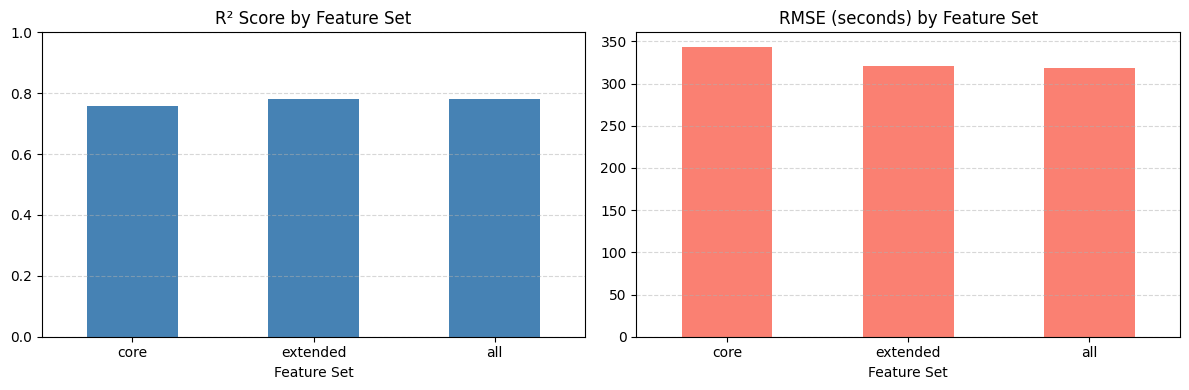


Best feature set: all


In [158]:
def evaluate_features(feature_list, X_tr, X_te, y_tr, y_te):
    """Evaluate a feature subset using the pre-split train / test sets."""
    Xtr = X_tr[feature_list].copy().replace([np.inf, -np.inf], np.nan)
    Xte = X_te[feature_list].copy().replace([np.inf, -np.inf], np.nan)
    Xtr.fillna(Xtr.median(), inplace=True)
    Xte.fillna(Xte.median(), inplace=True)

    model = RandomForestRegressor(
        n_estimators=150, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
    )
    model.fit(Xtr, y_tr)
    preds = model.predict(Xte)

    rmse     = np.sqrt(mean_squared_error(y_te, preds))
    r2       = r2_score(y_te, preds)
    rmse_sec = np.sqrt(mean_squared_error(np.expm1(y_te), np.expm1(preds)))

    return rmse, r2, rmse_sec


# ── Evaluation loop ───────────────────────────────────────────────────────────
# Use X_train_full / X_test_full from the initial split (Step 3 opening cell)
results = {}
for name, feats in {
    "core":     core_features,
    "extended": extended_features,
    "all":      all_features,
}.items():
    rmse, r2, rmse_sec = evaluate_features(
        feats, X_train_full, X_test_full, y_train_log, y_test_log
    )
    results[name] = {
        "RMSE (log)": round(rmse,     4),
        "R²":          round(r2,       4),
        "RMSE (sec)": round(rmse_sec, 1),
    }

results_df = pd.DataFrame(results).T
print(results_df)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results_df["R²"].plot(
    kind="bar", ax=axes[0], color="steelblue",
    title="R² Score by Feature Set", ylim=(0, 1)
)
results_df["RMSE (sec)"].plot(
    kind="bar", ax=axes[1], color="salmon",
    title="RMSE (seconds) by Feature Set"
)
for ax in axes:
    ax.set_xlabel("Feature Set")
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

best_set = results_df["RMSE (sec)"].idxmin()
print(f"\nBest feature set: {best_set}")

In [164]:
# ── 6.1  Lock in the winning feature set ─────────────────────────────────────
winning_features = {
    "core":     core_features,
    "extended": extended_features,
    "all":      all_features
}[best_set]

print(f"Winning feature set: '{best_set}'")
print(f"Features ({len(winning_features)}):")
for f in winning_features:
    print(f"  • {f}")

Winning feature set: 'all'
Features (22):
  • OSM_distance
  • distance_km
  • dropoff_cluster
  • pickup_cluster
  • dist_from_midtown
  • hour_cos
  • direction_deg
  • is_jfk_trip
  • circuity
  • hour_sin
  • is_lga_trip
  • day_of_week
  • cardinal_direction_West
  • cardinal_direction_North
  • late_night
  • afternoon_peak
  • is_weekend
  • month
  • cardinal_direction_South
  • morning_rush
  • cardinal_direction_East
  • passenger_count


In [165]:
# ── 6.2  Build final train / test matrices ───────────────────────────────────

X_train_final = X_train_full[winning_features].copy()
X_test_final  = X_test_full[winning_features].copy()

y_train_final = y_train_log.copy()   # log_trip_duration
y_test_final  = y_test_log.copy()

print(f"X_train_final shape : {X_train_final.shape}")
print(f"X_test_final  shape : {X_test_final.shape}")
X_train_final.sample(3)

X_train_final shape : (1151674, 22)
X_test_final  shape : (287919, 22)


,OSM_distance,distance_km,dropoff_cluster,pickup_cluster,dist_from_midtown,hour_cos,direction_deg,is_jfk_trip,circuity,hour_sin,is_lga_trip,day_of_week,cardinal_direction_West,cardinal_direction_North,late_night,afternoon_peak,is_weekend,month,cardinal_direction_South,morning_rush,cardinal_direction_East,passenger_count
453467,19312.3,14.163901,0,4,10.080987,-2.588190e-01,-158.886651,0,1363.487380,9.659258e-01,1,1,1,0,0,0,0,5,0,1,0,1
1340681,905.4,0.701272,1,1,4.269750,-1.836970e-16,79.756729,0,1291.082185,-1.000000e+00,0,3,0,1,0,0,0,1,0,0,0,4
575423,1259.4,0.523525,24,24,2.621628,-1.000000e+00,-81.837213,0,2405.615954,1.224647e-16,0,6,0,0,0,0,1,1,1,0,0,2


In [166]:
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train_final)   # fit on train ONLY
X_test_scaled  = scaler_final.transform(X_test_final)        # transform test with same params

# Wrap back in DataFrames to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=winning_features, index=X_train_final.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=winning_features, index=X_test_final.index)

print("Scaling applied. Sample of scaled training data:")
X_train_scaled.describe().T[['mean', 'std', 'min', 'max']].round(3)

Scaling applied. Sample of scaled training data:


,mean,std,min,max
OSM_distance,-0.0,1.0,-0.871,12.928
distance_km,0.0,1.0,-0.855,23.850
dropoff_cluster,0.0,1.0,-1.462,1.848
pickup_cluster,0.0,1.0,-1.420,1.918
dist_from_midtown,0.0,1.0,-0.922,8.949
hour_cos,0.0,1.0,-1.295,1.535
direction_deg,-0.0,1.0,-1.672,1.935
is_jfk_trip,-0.0,1.0,-0.172,5.820
circuity,0.0,1.0,-3.438,177.727
hour_sin,0.0,1.0,-1.186,1.787


In [168]:
# ── 6.4  Sanity check — no leakage, no NaN ───────────────────────────────────

assert X_train_scaled.isnull().sum().sum() == 0, "NaN found in training set!"
assert X_test_scaled.isnull().sum().sum()  == 0, "NaN found in test set!"
assert 'log_trip_duration' not in X_train_scaled.columns, "Target leaked into features!"
assert 'trip_duration'     not in X_train_scaled.columns, "Raw target leaked into features!"

print("✓ No NaN values")
print("✓ No target leakage")
print(f"✓ Training rows : {len(X_train_scaled):,}")
print(f"✓ Test rows     : {len(X_test_scaled):,}")
print(f"✓ Features      : {len(winning_features)}")

✓ No NaN values
✓ No target leakage
✓ Training rows : 1,151,674
✓ Test rows     : 287,919
✓ Features      : 22


In [ ]:
categorical_cols = ['pickup_cluster', 'dropoff_cluster', 'day_of_week']

for col in categorical_cols:
    X_train_final[col] = X_train_final[col].astype('category')
    X_test_final[col] = X_test_final[col].astype('category')

lgb_model = lgb.LGBMRegressor(
    n_estimators      = 4000,       
    learning_rate     = 0.03,        
    num_leaves        = 255,         
    max_depth         = -1,          
    min_child_samples = 150,      
    
    # Use Scikit-Learn aliases to stop the LightGBM warnings
    colsample_bytree  = 0.8,         # Equivalent to feature_fraction
    subsample         = 0.9,         # Equivalent to bagging_fraction
    subsample_freq    = 1,           # Equivalent to bagging_freq
    
    reg_alpha         = 0.1,         # L1 regularization
    reg_lambda        = 1.0,         # L2 regularization
    random_state      = RANDOM_STATE,
    n_jobs            = -1,
)

# 3. Fit the model
lgb_model.fit(
    X_train_final, y_train_final,
    eval_set=[(X_test_final, y_test_final)],
    categorical_feature=categorical_cols, 
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True), 
        lgb.log_evaluation(period=200),
    ]
)

y_pred_lgb_log  = lgb_model.predict(X_test_final)
y_pred_lgb_real = np.expm1(y_pred_lgb_log)
y_test_real     = np.expm1(y_test_final)

lgb_rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_lgb_real))
lgb_r2   = r2_score(y_test_real, y_pred_lgb_real)

print(f"LightGBM  RMSE : {lgb_rmse:.2f} seconds")
print(f"LightGBM  R²   : {lgb_r2:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033088 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1434
[LightGBM] [Info] Number of data points in the train set: 1151674, number of used features: 22
[LightGBM] [Info] Start training from score 6.482120
Training until validation scores don't improve for 100 rounds
[200]	valid_0's l2: 0.0936991
[400]	valid_0's l2: 0.0895512
[600]	valid_0's l2: 0.0884108
[800]	valid_0's l2: 0.0878011
[1000]	valid_0's l2: 0.0874244
[1200]	valid_0's l2: 0.0871646
[1400]	valid_0's l2: 0.0869493
[1600]	valid_0's l2: 0.0868036
[1800]	valid_0's l2: 0.0867028
[2000]	valid_0's l2: 0.0866162
[2200]	valid_0's l2: 0.0865589
[2400]	valid_0's l2: 0.0865231
[2600]	valid_0's l2: 0.0864865
[2800]	valid_0's l2: 0.0864642
Early stopping, best iteration is:
[2896]	valid_0's l2: 0.0864578
LightGBM  RMSE : 280.59 seconds
Li

In [ ]:
import joblib
joblib.dump(lgb_model, "lgbm_nyc_taxi_duration_model.joblib")

['lgbm_nyc_taxi_duration_model.joblib']

<Figure size 1000x600 with 0 Axes>

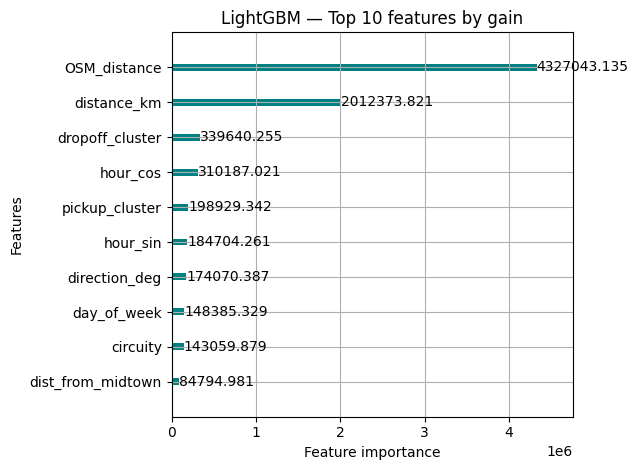

In [170]:
# ── 7.1  Feature Importance from LightGBM ───────────────────────────────────
plt.figure(figsize=(10,6))
lgb.plot_importance(lgb_model, max_num_features=10, importance_type='gain', color='teal')
plt.title("LightGBM — Top 10 features by gain")
plt.tight_layout()
plt.show()


In [172]:
importance_df = pd.DataFrame({
    'Feature': X_test_final.columns,
    'Importance': lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance_df.to_csv('powerbi_feature_importance.csv', index=False)